# **ANOMALY DETECTION WITH LSTM AUTOENCODER**


## **Problem Statement**
Financial markets are highly dynamic and influenced by numerous factors, including macroeconomic indicators, investor sentiment, and global events. Detecting anomalies in stock prices is essential for uncovering unusual patterns that may signal market manipulation, financial fraud, or rare investment opportunities.

In this project, I applied a Long Short-Term Memory (LSTM) autoencoder to reconstruct stock price sequences. If the model struggles to accurately reconstruct a sequence (i.e., produces a large reconstruction error), the sequence likely contains anomalous behavior. Anomalies are flagged when the deviation between the actual and reconstructed price exceeds the 95th percentile of the historical reconstruction error (MAE). This thresholding strategy highlights only the most unusual price movements. LSTMs were chosen because they effectively model long-term temporal dependencies while balancing the need to forget outdated information and incorporate new patterns.

The results demonstrate that this approach can be valuable for traders, analysts, and financial institutions seeking to: i) identify arbitrage opportunities, ii) enhance risk management strategies, and iii) detect market irregularities in real time. Beyond finance, this anomaly detection framework generalizes to domains such as machine sensors, cybersecurity, and healthcare.

### **(1) Fetch Real Stock Price Data**
Download the adjusted stock prices of Tesla from Yahoo Finance since 2015.

In [ ]:
# install yfinance
!pip install yfinance

In [ ]:
# Import libraries
import pandas as pd
from copy import copy
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import datetime
import yfinance as yf
from tensorflow import keras
import seaborn as sns

In [ ]:
# Download the adjusted stock prices from 2015 to the current stock price from Yahoo Finance
ticker = ['TSLA']
df_prices = pd.DataFrame()

start_date = "2015-01-01"
end_date = "2025-12-31" # today's date
#end_date = datetime.date.today() # today's date
stock_prices = yf.download(ticker, start_date, end_date, progress = False, auto_adjust=True)

stock_prices.columns = stock_prices.columns.droplevel(1)  # Drop the "Ticker" level

stock_prices = stock_prices.reset_index()
df_prices["Date"] = stock_prices["Date"]
df_prices["Close"] = stock_prices["Close"]
df_prices

,Date,Close
0,2015-01-02,14.620667
1,2015-01-05,14.006000
2,2015-01-06,14.085333
3,2015-01-07,14.063333
4,2015-01-08,14.041333
...,...,...
2760,2025-12-23,485.559998
2761,2025-12-24,485.399994
2762,2025-12-26,475.190002
2763,2025-12-29,459.640015


### **(2) Exploratory Data Analysis**
Analyzing the historical TSLA shares and check if any missing prices, before applying the machine learning model.

In [ ]:
# Check if any missing data
df_prices.isnull().sum()

,0
Date,0
Close,0


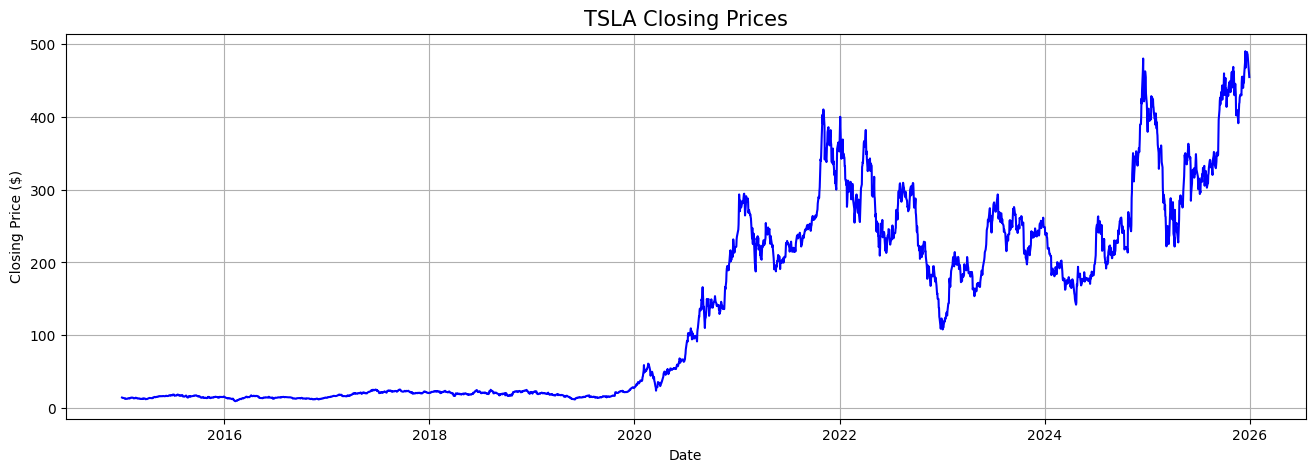

In [ ]:
# Plot the line chart of the closing prices
plt.figure(figsize=(16, 5))
plt.plot(df_prices['Date'], df_prices["Close"], color='b')
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.title(ticker[0] +" Closing Prices", size=15)

plt.grid(True)
plt.show()

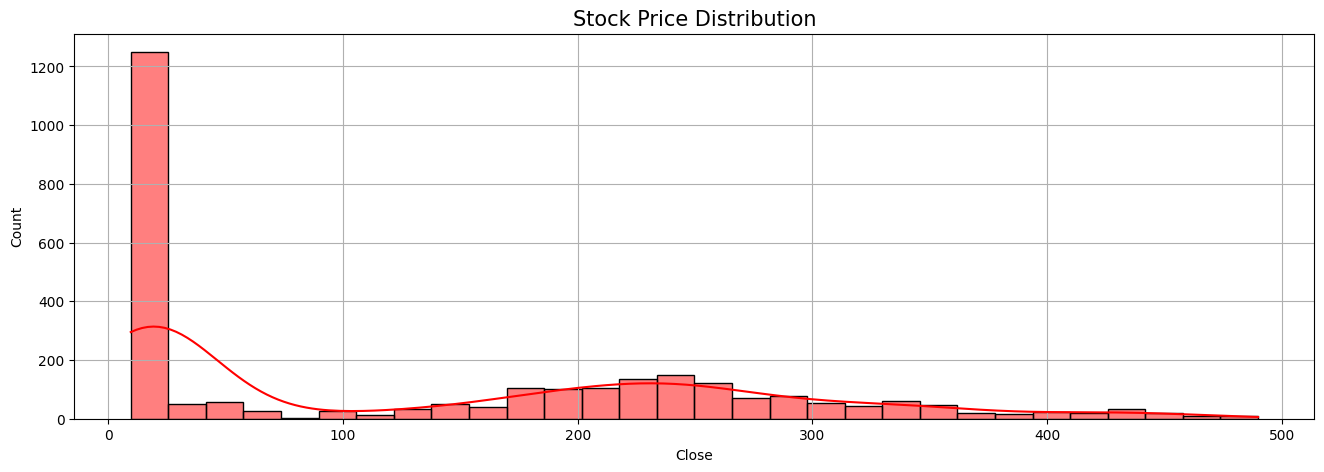

In [ ]:
# check the distribution and range of the stock prices
plt.figure(figsize=(16, 5))
sns.histplot(df_prices['Close'], kde = True, bins = 30, color='r')
plt.title('Stock Price Distribution', size=15)

plt.grid(True)
plt.show()

### **(3) Data Preprocessing**
The code extracts the closing prices from a dataset and splits them into training (70%) and test (30%) sets. It then uses a MinMaxScaler to normalize the data into the range [0, 1], fitting the scaler only on the training set to avoid data leakage, and applying the same transformation to the test set for consistency.

In [ ]:
# Get the closing prices in 2-D array
prices = df_prices[['Close']].values
prices

array([[ 14.62066746],
       [ 14.00599957],
       [ 14.08533287],
       ...,
       [475.19000244],
       [459.64001465],
       [454.42999268]])

In [ ]:
# Split the dataset into training and test data at a ratio of 7:3
split = int(len(prices) * 0.7)
train, test = prices[:split], prices[split:]

In [ ]:
train.shape

(1935, 1)

In [ ]:
test.shape

(830, 1)

In [ ]:
# Normalize all prices to value between 0 and 1
scaler = MinMaxScaler()

# Fit scaler on training data
train_scaled = scaler.fit_transform(train)

# Apply the same scaler to test data
test_scaled = scaler.transform(test)

In [ ]:
train_scaled

array([[0.01259433],
       [0.01105916],
       [0.0112573 ],
       ...,
       [0.6614568 ],
       [0.68463409],
       [0.69852047]])

### **(4) Create Sequences with Timestep**
Define a time window of 30 timesteps, as the model will look at the past 30 closing prices to predict the next one. The training and test sets are transformed into sequences (X_train, X_test) and corresponding targets (y_train, y_test). The input arrays are reshaped into 3D format (samples, time_steps, features), which is the required input shape for LSTM networks.

In [ ]:
# Initialize empty lists to hold training and testing sequences + targets
X_train = []
y_train = []
X_test = []
y_test = []

# Set the time window (number of past steps the LSTM will "look back" to predict/reconstruct)
time_step = 30  # The model will use the previous 30 time steps to learn/reconstruct

# Loop through the training dataset
for i in range(time_step, len(train_scaled)):
    # Take a sliding window of the previous 'time_step' values as input (features)
    X_train.append(train_scaled[i-time_step:i, 0])
    # Take the current value (at time i) as the target (label)
    y_train.append(train_scaled[i, 0])

# Same applied for the test data
for i in range(time_step, len(test_scaled)):
    X_test.append(test_scaled[i-time_step:i, 0])
    y_test.append(test_scaled[i, 0])

In [ ]:
# Convert the lists into array format
X_train = np.asarray(X_train)
X_test = np.asarray(X_test)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

In [ ]:
# Reshape the arrays to 3D arrays for feeding into the LSTM model
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
X_train.shape, X_test.shape

((1905, 30, 1), (800, 30, 1))

### **(5) Build LSTM Autoencoder**

In [ ]:
T = X_train.shape[1]     # no. of timesteps
F = X_train.shape[2]     # no. of features

# ---------- Input Layer ----------
inputs = keras.layers.Input(shape=(T, F))

# ---------- Encoder ----------
x = keras.layers.LSTM(64, return_sequences=True)(inputs)
x = keras.layers.Dropout(0.4)(x)
x = keras.layers.LSTM(32, return_sequences=False)(x)
x = keras.layers.Dropout(0.4)(x)

# ---------- Decoder ----------
x = keras.layers.RepeatVector(T)(x)
x = keras.layers.LSTM(64, return_sequences=True)(x)
x = keras.layers.Dropout(0.4)(x)
x = keras.layers.LSTM(32, return_sequences=True)(x)
x = keras.layers.Dropout(0.4)(x)

# ---------- Output Layer ----------
outputs = keras.layers.TimeDistributed(
    keras.layers.Dense(F, activation='linear')
)(x)

autoencoder = keras.Model(inputs=inputs, outputs=outputs)
autoencoder.compile(optimizer='adam', loss='mae')  # MAE is common for recon error
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,593 (260.13 KB)

 Trainable params: 66,593 (260.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# condition for early stopping the model training
es = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_train, X_train,              # reconstruct the input
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    shuffle=False,
    callbacks=[es]
)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0234 - val_loss: 0.5548
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0370 - val_loss: 0.2623
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0377 - val_loss: 0.1564
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0150 - val_loss: 0.2031
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0268 - val_loss: 0.1469
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0109 - val_loss: 0.1065
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0087 - val_loss: 0.1119
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0112 - val_loss: 0.2446
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0142 - val_loss: 0.0973
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0169 - val_loss: 0.1038
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0119 - val_loss: 0.2567
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0

### **(6) Reconstructing Data Sequences**
The trained autoencoder is used to reconstruct both the training and test sequences. Predictions on X_train (predicted_train) and X_test (predicted_test) produce outputs with the same shape as the inputs.

In [ ]:
X_train.shape

(1905, 30, 1)

In [ ]:
# Use the trained autoencoder to reconstruct the training sequences
# The output will have the same shape as the input (X_train)
predicted_train = autoencoder.predict(X_train, verbose=0)

predicted_train.shape # the input and output of the training sequence are the same shape

(1905, 30, 1)

In [ ]:
X_test.shape

(800, 30, 1)

In [ ]:
# Reconstruct the test set
predicted_test = autoencoder.predict(X_test, verbose=0)

# The input and output of the test sequence are the same shape
predicted_test.shape

(800, 30, 1)

### **(7) Detecting Anomalies**
We calculate the reconstruction error (MAE) for each time window in the training data set and defines an anomaly detection threshold as the 95th percentile of training errors. It then computes reconstruction errors for the test data. Anomaly is flagged when the reconstruction error exceeds the threshold.

In [ ]:
# Per-window reconstruction error (MAE across time and feature) of the training data
train_mae_loss = np.mean(np.abs(predicted_train - X_train), axis=(1,2))

# Set the thresold as 95th percentile of the training reconstruction error for detecting anomalies
threshold = np.quantile(train_mae_loss, 0.95)
print("Reconstruction error threshold (train-based):", threshold)

Reconstruction error threshold (train-based): 0.10802330500433868


In [ ]:
# Reconstruction error (MAE) of test data
test_mae_loss = np.mean(np.abs(predicted_test - X_test), axis=(1, 2))

In [ ]:
# Create a dataframe for storing the results of anomalies for the test data
test_anomaly = df_prices[split+time_step:][['Date']]
test_anomaly['Close'] = df_prices[split+time_step:]['Close']
test_anomaly['MAE_Loss'] = test_mae_loss
test_anomaly['Threshold'] = threshold

# Anomaly is detected if the reconstruction error (test) > thresold error
test_anomaly['Anomaly'] = test_anomaly['MAE_Loss'] > test_anomaly['Threshold']
test_anomaly

,Date,Close,MAE_Loss,Threshold,Anomaly
1965,2022-10-21,214.440002,0.125092,0.108023,True
1966,2022-10-24,211.250000,0.126350,0.108023,True
1967,2022-10-25,222.419998,0.126878,0.108023,True
1968,2022-10-26,224.639999,0.127110,0.108023,True
1969,2022-10-27,225.089996,0.125547,0.108023,True
...,...,...,...,...,...
2760,2025-12-23,485.559998,0.298670,0.108023,True
2761,2025-12-24,485.399994,0.301278,0.108023,True
2762,2025-12-26,475.190002,0.304360,0.108023,True
2763,2025-12-29,459.640015,0.307448,0.108023,True


In [ ]:
# Extract the prices and dates with anomalies identified
anomalies = test_anomaly.loc[test_anomaly['Anomaly'] == True]
anomalies

,Date,Close,MAE_Loss,Threshold,Anomaly
1965,2022-10-21,214.440002,0.125092,0.108023,True
1966,2022-10-24,211.250000,0.126350,0.108023,True
1967,2022-10-25,222.419998,0.126878,0.108023,True
1968,2022-10-26,224.639999,0.127110,0.108023,True
1969,2022-10-27,225.089996,0.125547,0.108023,True
...,...,...,...,...,...
2760,2025-12-23,485.559998,0.298670,0.108023,True
2761,2025-12-24,485.399994,0.301278,0.108023,True
2762,2025-12-26,475.190002,0.304360,0.108023,True
2763,2025-12-29,459.640015,0.307448,0.108023,True


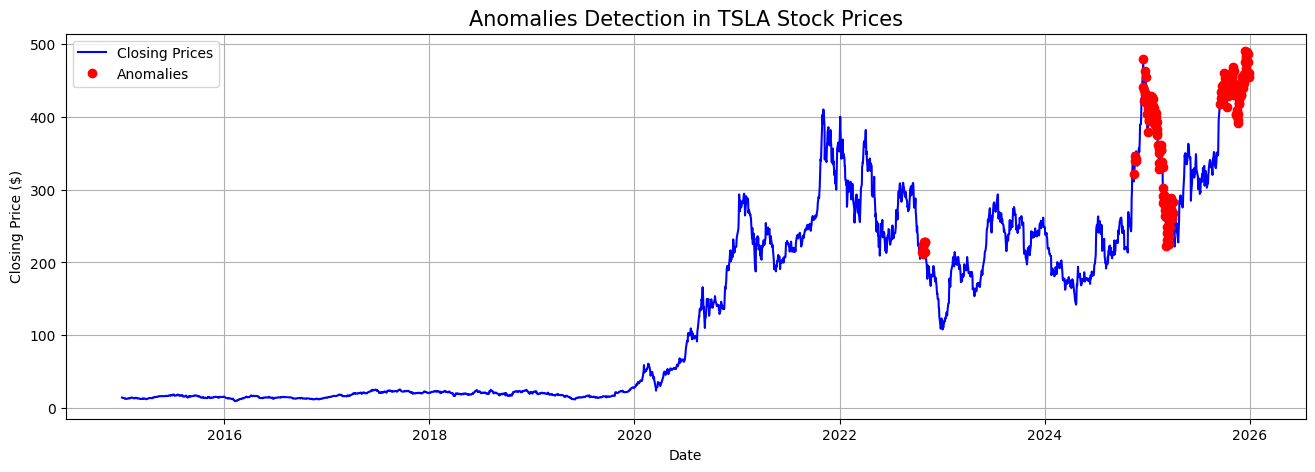

In [ ]:
plt.figure(figsize=(16, 5))

# Plot the main data points as discrete dots
plt.plot(df_prices['Date'], df_prices["Close"], marker='', color='b', linestyle='-', label='Closing Prices')

# Plot the anomalies as red dots
plt.plot(anomalies['Date'], anomalies["Close"], marker='o', color='r', linestyle='', label='Anomalies')

# Labels and title
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.title("Anomalies Detection in " + ticker[0] + " Stock Prices", size=15)

plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import plotly.express as px

# Main plot with stock closing prices
fig = px.line(df_prices, x="Date", y="Close", title=f"Anomalies Detection in {ticker[0]} Stock Prices",
              labels={"Date": "Date", "Close": "Closing Price ($)"})

# Add anomaly points
fig.add_scatter(x=anomalies["Date"], y=anomalies["Close"],
                mode="markers", marker=dict(color='red', size=8),
                name="Anomalies")

# Show grid and legend
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Closing Price ($)",
    hovermode="x unified"
)

fig.show()

### **(8) Model Evaluation**
We evaluate the model by comparing the reconstruction errors of the training data and test data, with the latter showing a significantly higher MAE due to the presence of anomalies. Additionally, the training loss (blue curve) remains low and steady showing the model is learning the training data well. The validation loss curve (orange curve) is bumpy and shows great oscillation, as the unusual price pattern (anomalies) are hard to reconstruct resulting to large reconstruction error.

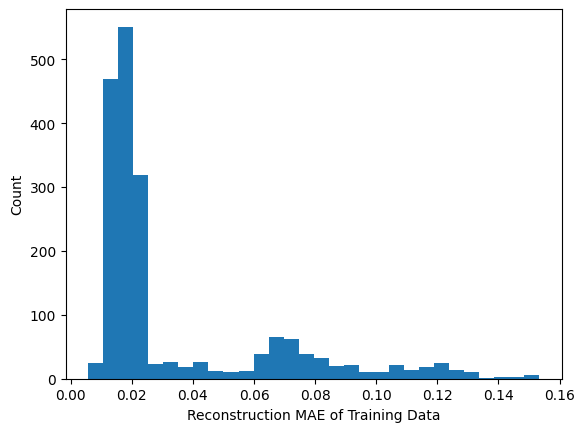

In [ ]:
# Plot the distribution of the reconstruction MAE (training data)
plt.hist(train_mae_loss, bins=30)
plt.xlabel("Reconstruction MAE of Training Data")
plt.ylabel("Count")
plt.show()

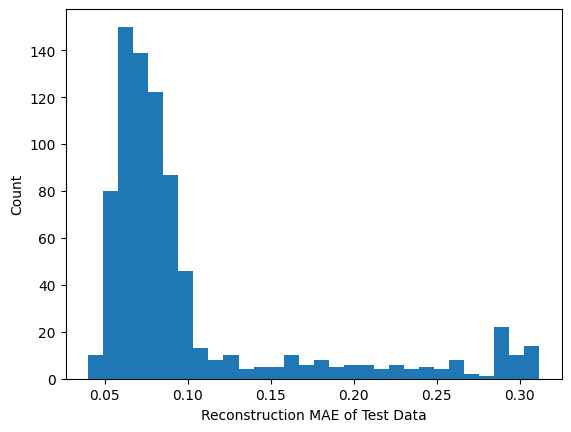

In [ ]:
# Plot the distribution of the reconstruction MAE (test data)
plt.hist(test_mae_loss, bins=30)
plt.xlabel('Reconstruction MAE of Test Data')
plt.ylabel('Count')
plt.show()

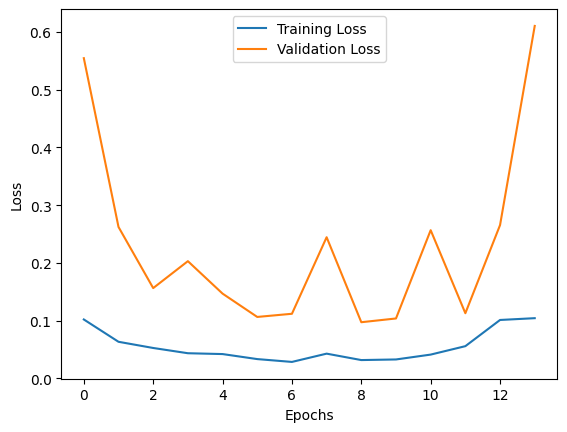

In [ ]:
# Plot the graphs of training loss and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## **(9) What actually happened in real life?**


The major anomalies happened between Nov and Dec 2024, which are in-line with the actual price movement during the same period.


**Nov 2024**: Share prices surged on optimism of Donald Trump's election victory.

**Dec 2024**: After TSLA shares reached its all-time high on 17th Decemeber 2024, the shares plunged, due to weak market sentiment on trade tariffs by the US as well as TESLA's declining sales data.

**Mar 2025**: Shares extended further losses, amid market concerns over Elon Musk’s involvement with the Trump administration as well as the falling new vehicle sales.

**Sep 2025**: Elon Musk buying back $1bn in Tesla Shares, a signal of confidence of the company

**Oct-Dec 2025**: TSLA shares saw a strong recovery, thanks to strategic narrative shifts - positioning as an artificial intelligence (AI) and autonomy leader, not just an electric vehicle (EV) maker.

**By identifying anomalies in the stock prices, this model provides significant insights in trading opportunities, risk management as well as fraud detection.**